# Chapter 3 - Convex Hulls in Two Dimensions

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 3, printed pages 63-100: convexity, extreme points, naive hull tests, gift wrapping, QuickHull, Graham scan, lower bounds, incremental construction, divide-and-conquer, and related exercises such as rotating calipers and onion layers. The chapter is one of the clearest examples of the book's style: define a geometric object, build several algorithms for the same object, and use complexity analysis to explain why some ideas are mainly pedagogical while others are practical.

A convex hull can be described in several equivalent ways: the smallest convex set containing the input, the intersection of all convex supersets, or the polygon whose boundary contains the extreme points. Algorithmically, those descriptions lead to different tests. A point is nonextreme if it lies inside a triangle formed by three other points. An edge is extreme if all other points lie on the same side of the directed line. Gift wrapping walks from one extreme edge to the next and is output-sensitive with cost `O(nh)`, where `h` is the number of hull vertices. QuickHull uses farthest-point recursion and triangle discards; it is often fast but has quadratic worst cases. Graham scan sorts points angularly and then maintains a stack, giving the familiar `O(n log n)` bound. The lower-bound section explains why ordered hull output is at least as hard as sorting by placing numbers on a parabola.

The visuals below compare algorithms on the same point set, mark nonextreme points by triangle containment, show the parabola reduction, and plot how the main asymptotic costs scale with hull size.


## Visual Storyboard

1. **Extreme vs nonextreme.** A brute-force triangle containment test marks interior points and leaves the extreme set visible.
2. **Three hull algorithms.** Gift wrapping, QuickHull, and Graham scan are run on the same points and checked for identical hull vertices.
3. **Graham stack trace.** The scan records push/pop decisions so the orientation predicate is visible as an algorithmic guardrail.
4. **Parabola lower bound.** Numbers placed at `(x, x^2)` become hull vertices in sorted order, making sorting reducible to ordered hull output.
5. **Complexity laboratory.** Curves for `O(nh)`, average-looking QuickHull intuition, `O(n log n)`, and output-sensitive `O(n log h)` show when hull size matters.
6. **Extension map.** Incremental construction, divide-and-conquer, rotating calipers, and onion peeling are placed as later moves once the hull is available.


## Library Routing

The notebook uses no black-box hull routine for the central algorithms. `numpy` stores points and computes determinants; `matplotlib` draws point sets, recursion regions, and comparison plots; `networkx` is not needed here because the chapter is about ordered boundary structures rather than arbitrary graphs. Book-local artifact helpers save figures, tables, and JSON checks under the chapter artifact subtree. This makes the algorithms inspectable in the same spirit as the C code from the source span.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-03-convex-hulls-in-two-dimensions"
UNIT_TITLE = "Convex Hulls in Two Dimensions"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "nonextreme-triangle-test", "visual": "nonextreme-triangle-test.png", "check": "every_marked_point_has_witness_triangle"},
    {"move": "algorithm-comparison", "visual": "hull-algorithm-comparison.png", "check": "gift_quick_graham_agree"},
    {"move": "graham-stack", "visual": "graham-stack-trace.png", "check": "stack_never_keeps_right_turn"},
    {"move": "sorting-lower-bound", "visual": "parabola-sorting-reduction.png", "check": "parabola_hull_order_sorts_inputs"},
    {"move": "complexity-lab", "visual": "hull-complexity-lab.png", "check": "output_sensitive_cost_drops_when_h_is_small"},
]
routing_rows = [
    {"source_topic": "convexity, extreme points, and naive tests", "artifact": "nonextreme-triangle-test.png", "code_cell": "extreme point tests"},
    {"source_topic": "gift wrapping", "artifact": "hull-algorithm-comparison.png", "code_cell": "gift_wrap"},
    {"source_topic": "QuickHull", "artifact": "hull-algorithm-comparison.png", "code_cell": "quickhull"},
    {"source_topic": "Graham scan and stack invariant", "artifact": "graham-stack-trace.png", "code_cell": "graham_scan"},
    {"source_topic": "sorting lower bound by parabola", "artifact": "parabola-sorting-reduction.png", "code_cell": "parabola reduction"},
    {"source_topic": "incremental, divide-and-conquer, output-sensitive algorithms", "artifact": "hull-complexity-lab.png", "code_cell": "complexity lab"},
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 63-100", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "63-100", "pdf_pages": "72-109"},
    "covered_ideas": [
        "convexity and extreme points",
        "nonextreme point inside triangle and extreme edge tests",
        "gift wrapping O(nh)",
        "QuickHull recursion and worst-case warning",
        "Graham scan stack invariant and O(n log n)",
        "sorting lower bound via parabola",
        "incremental, divide-and-conquer, and output-sensitive hull algorithms",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-03-convex-hulls-in-two-dimensions",
  "storyboard_items": 5
}


## Hull Primitives and Three Algorithms

The same orientation determinant from Chapter 1 drives the whole chapter. Gift wrapping repeatedly chooses the point that makes every other point lie to one side of the candidate edge. Graham scan sorts by angle around a pivot and then pops the stack whenever the next point would create a right turn. QuickHull splits the set by a baseline, picks the farthest point from a segment, and recurses on the two exposed subproblems. The implementations below are compact rather than industrial, but they expose the decisions that matter.


In [2]:
EPS = 1e-9
points = np.array([
    [0.0, 0.0], [0.4, 2.5], [1.2, 3.4], [2.4, 3.1], [3.5, 2.3], [4.1, 0.6],
    [3.1, -0.7], [1.5, -0.9], [-0.6, 0.7], [1.0, 1.1], [1.9, 0.3], [2.6, 1.2],
    [0.9, 2.0], [2.0, 2.1], [3.1, 0.2], [0.2, 1.2]
], dtype=float)

def orient(a, b, c):
    return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))

def dist2(a, b):
    d = np.asarray(a) - np.asarray(b)
    return float(d @ d)

def polar_order(center, ids):
    return sorted(ids, key=lambda i: (math.atan2(points[i, 1] - center[1], points[i, 0] - center[0]), dist2(points[i], center)))

def gift_wrap(pts):
    n = len(pts)
    start = min(range(n), key=lambda i: (pts[i, 0], pts[i, 1]))
    hull = []
    current = start
    while True:
        hull.append(current)
        candidate = (current + 1) % n
        for r in range(n):
            if r == current:
                continue
            turn = orient(pts[current], pts[candidate], pts[r])
            if turn < -EPS or (abs(turn) <= EPS and dist2(pts[current], pts[r]) > dist2(pts[current], pts[candidate])):
                candidate = r
        current = candidate
        if current == start:
            break
    return hull

def graham_scan(pts):
    pivot = min(range(len(pts)), key=lambda i: (pts[i, 1], pts[i, 0]))
    order = [pivot] + sorted([i for i in range(len(pts)) if i != pivot], key=lambda i: (math.atan2(pts[i, 1] - pts[pivot, 1], pts[i, 0] - pts[pivot, 0]), dist2(pts[pivot], pts[i])))
    stack = []
    trace = []
    for idx in order:
        while len(stack) >= 2 and orient(pts[stack[-2]], pts[stack[-1]], pts[idx]) <= EPS:
            popped = stack.pop()
            trace.append({"action": "pop", "point": int(popped), "incoming": int(idx)})
        stack.append(idx)
        trace.append({"action": "push", "point": int(idx), "stack": [int(s) for s in stack]})
    return stack, trace

def quickhull(pts):
    left = min(range(len(pts)), key=lambda i: (pts[i, 0], pts[i, 1]))
    right = max(range(len(pts)), key=lambda i: (pts[i, 0], pts[i, 1]))
    regions = []
    hull_edges = []
    def recurse(a, b, candidates):
        if not candidates:
            hull_edges.append((a, b))
            return
        far = max(candidates, key=lambda i: abs(orient(pts[a], pts[b], pts[i])))
        regions.append({"edge": [int(a), int(b)], "farthest": int(far), "discarded_triangle": [int(a), int(far), int(b)], "candidate_count": len(candidates)})
        left_af = [i for i in candidates if orient(pts[a], pts[far], pts[i]) > EPS]
        left_fb = [i for i in candidates if orient(pts[far], pts[b], pts[i]) > EPS]
        recurse(a, far, left_af)
        recurse(far, b, left_fb)
    upper = [i for i in range(len(pts)) if orient(pts[left], pts[right], pts[i]) > EPS]
    lower = [i for i in range(len(pts)) if orient(pts[right], pts[left], pts[i]) > EPS]
    recurse(left, right, upper)
    recurse(right, left, lower)
    ids = sorted({i for edge in hull_edges for i in edge})
    center = pts[ids].mean(axis=0)
    ordered = sorted(ids, key=lambda i: math.atan2(pts[i, 1] - center[1], pts[i, 0] - center[0]))
    return ordered, regions

gift_ids = gift_wrap(points)
graham_ids, graham_trace = graham_scan(points)
quick_ids, quick_regions = quickhull(points)
# Normalize all hulls to sets for agreement; ordered starts can differ.
hull_sets_agree = set(gift_ids) == set(graham_ids) == set(quick_ids)
print(json.dumps({"gift_h": len(gift_ids), "graham_h": len(graham_ids), "quick_h": len(quick_ids), "agree": hull_sets_agree}, indent=2))


{
  "gift_h": 9,
  "graham_h": 9,
  "quick_h": 9,
  "agree": true
}


C:\Users\rahul\AppData\Local\Temp\ipykernel_1180\3437477522.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))


## Nonextreme Points and Naive Hull Tests

The source span starts with intentionally slow algorithms because they clarify the object. A point inside a triangle formed by three other input points cannot be a hull vertex. Testing all quadruples gives an `O(n^4)` nonextreme-point algorithm. Testing all directed edges and asking whether all other points lie on one side gives an `O(n^3)` extreme-edge algorithm. Both are too slow for large inputs, but they are excellent sanity checks for faster routines.


C:\Users\rahul\AppData\Local\Temp\ipykernel_1180\3437477522.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))


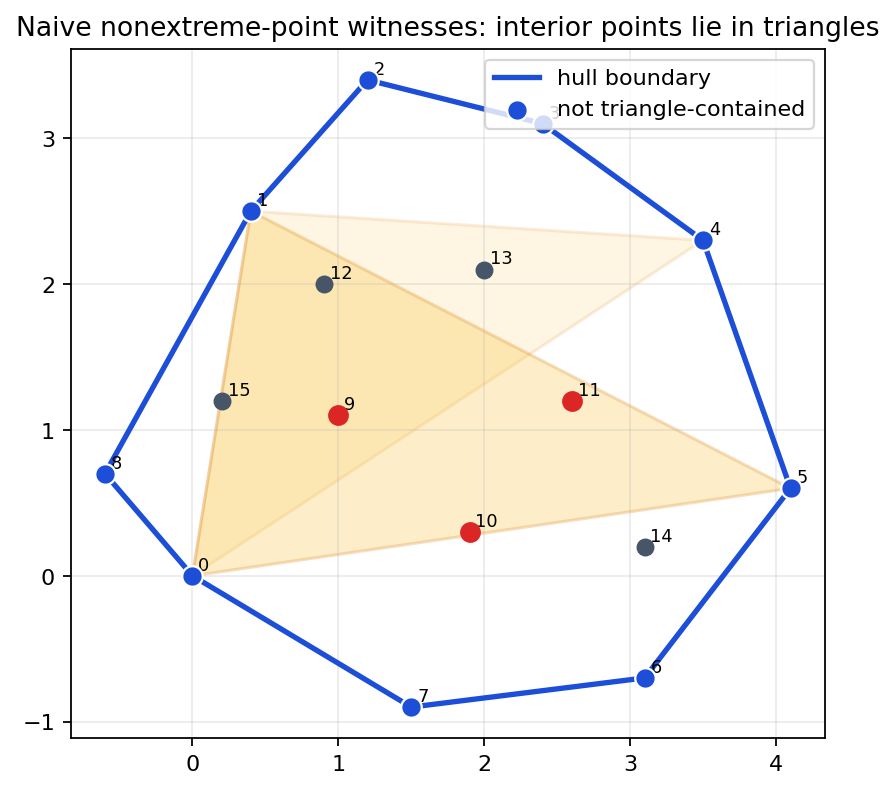

In [3]:
def point_in_triangle(p, a, b, c):
    signs = [orient(a, b, p), orient(b, c, p), orient(c, a, p)]
    return not (any(s < -EPS for s in signs) and any(s > EPS for s in signs))

nonextreme_witness = {}
for p_idx in range(len(points)):
    for tri in combinations([i for i in range(len(points)) if i != p_idx], 3):
        a, b, c = points[list(tri)]
        if abs(orient(a, b, c)) > EPS and point_in_triangle(points[p_idx], a, b, c):
            nonextreme_witness[p_idx] = tri
            break
extreme_by_triangle = sorted(set(range(len(points))) - set(nonextreme_witness))

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.scatter(points[:, 0], points[:, 1], color="#475569", s=50, zorder=3)
for i, p in enumerate(points):
    ax.text(p[0] + 0.04, p[1] + 0.04, str(i), fontsize=8)
for p_idx, tri in list(nonextreme_witness.items())[:3]:
    tri_pts = points[list(tri)]
    ax.fill(tri_pts[:, 0], tri_pts[:, 1], alpha=0.13, edgecolor="#d97706", facecolor="#fbbf24", linewidth=1.4)
    ax.scatter(*points[p_idx], color="#dc2626", s=70, zorder=4)
hull_closed = points[gift_ids + [gift_ids[0]]]
ax.plot(hull_closed[:, 0], hull_closed[:, 1], color="#1d4ed8", linewidth=2.4, label="hull boundary")
ax.scatter(points[extreme_by_triangle, 0], points[extreme_by_triangle, 1], color="#1d4ed8", s=85, edgecolor="white", zorder=5, label="not triangle-contained")
ax.set_title("Naive nonextreme-point witnesses: interior points lie in triangles")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
nonextreme_fig_path = save_matplotlib(fig, FIGURES / "nonextreme-triangle-test.png")
plt.close(fig)

nonextreme_path = save_json({
    "nonextreme_witness": {str(k): list(map(int, v)) for k, v in nonextreme_witness.items()},
    "extreme_candidates_by_triangle_test": [int(i) for i in extreme_by_triangle],
    "hull_vertices": [int(i) for i in gift_ids],
    "checks": {
        "every_marked_point_has_witness_triangle": len(nonextreme_witness) > 0 and all(len(v) == 3 for v in nonextreme_witness.values()),
        "triangle_test_extremes_match_hull_set": set(extreme_by_triangle) == set(gift_ids),
    },
}, CHECKS / "nonextreme-triangle-test.json")
display_artifact(nonextreme_fig_path, width=720)


## Gift Wrapping, QuickHull, and Graham Scan Side by Side

The three algorithms below agree on the hull but arrive there differently. Gift wrapping sees only the next exposed edge and pays for all input points at each hull vertex. QuickHull tries to discard large triangles and recurse on smaller outside sets; the plot records the farthest-point triangles. Graham scan pays up front for angular sorting, then uses the orientation predicate to maintain a left-turn stack. The stack trace is useful because it makes the proof invariant concrete: after processing a prefix of the angular order, the stack is the hull of that prefix.


C:\Users\rahul\AppData\Local\Temp\ipykernel_1180\3437477522.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))


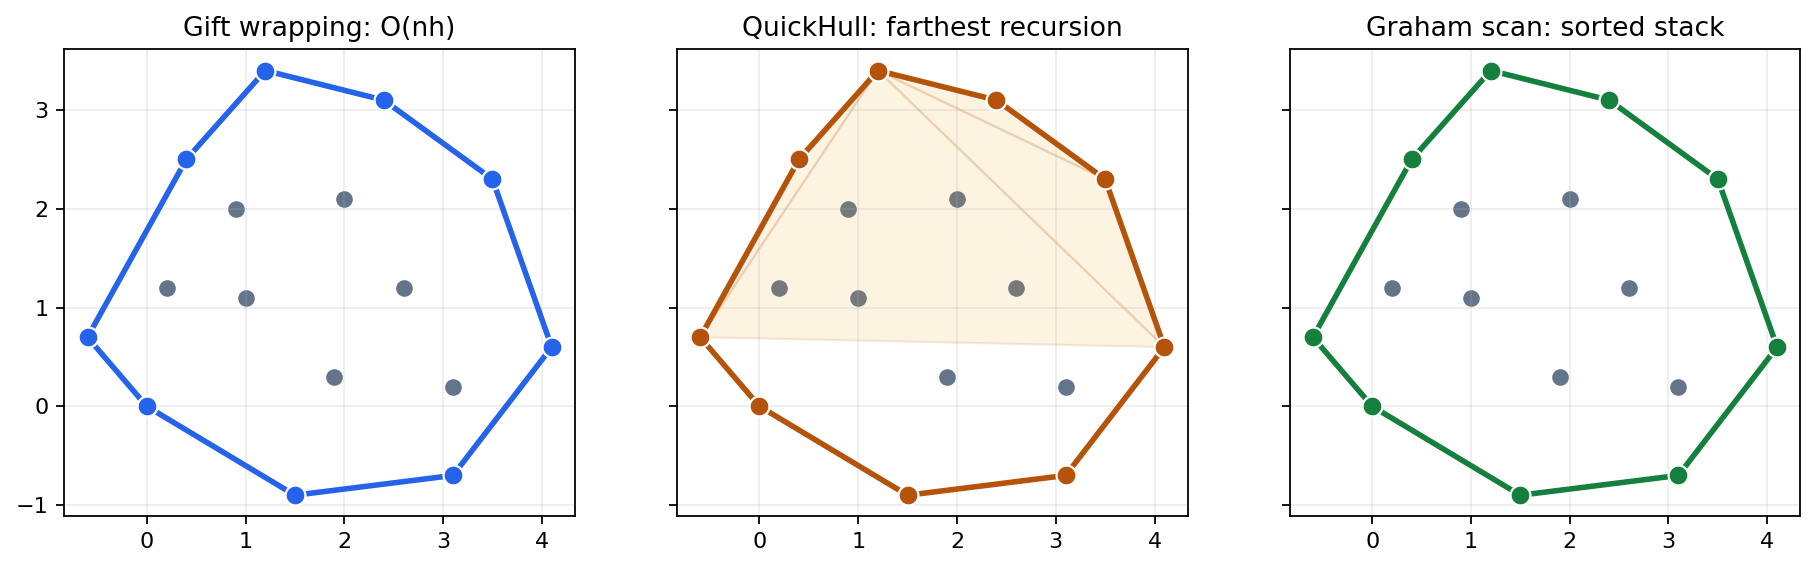

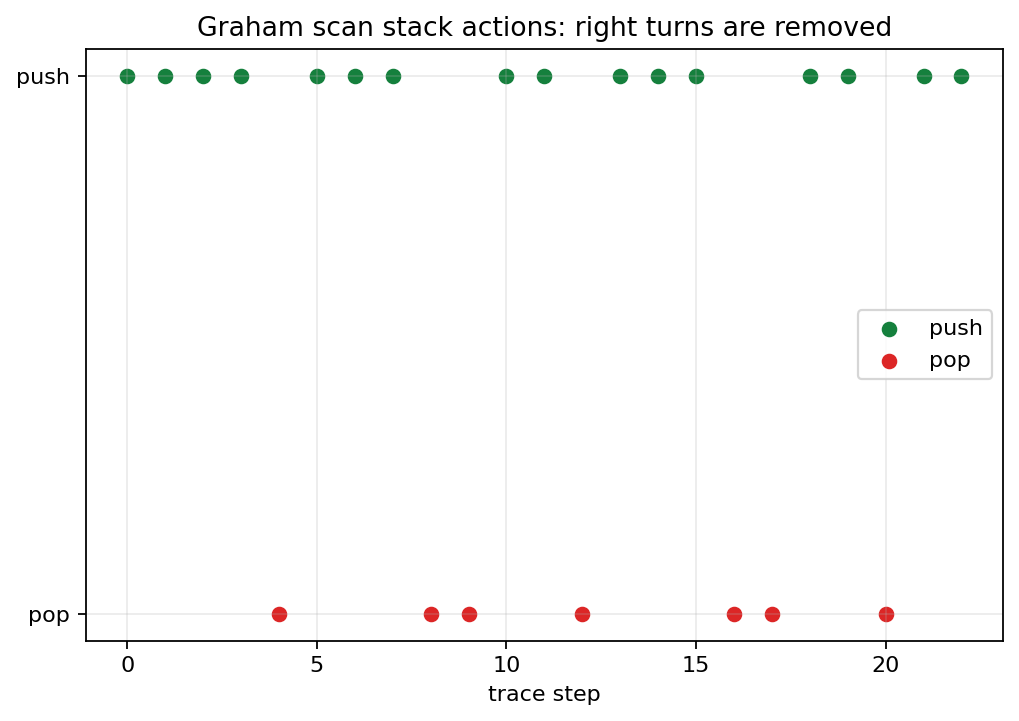

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharex=True, sharey=True)
for ax, ids, title, color in [
    (axes[0], gift_ids, "Gift wrapping: O(nh)", "#2563eb"),
    (axes[1], quick_ids, "QuickHull: farthest recursion", "#b45309"),
    (axes[2], graham_ids, "Graham scan: sorted stack", "#15803d"),
]:
    ax.scatter(points[:, 0], points[:, 1], color="#64748b", s=42)
    closed = points[ids + [ids[0]]]
    ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=2.5)
    for i in ids:
        ax.scatter(*points[i], color=color, s=80, edgecolor="white", zorder=4)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.22)
for region in quick_regions[:4]:
    tri_pts = points[region["discarded_triangle"]]
    axes[1].fill(tri_pts[:, 0], tri_pts[:, 1], color="#f59e0b", alpha=0.12, edgecolor="#b45309")
comparison_fig_path = save_matplotlib(fig, FIGURES / "hull-algorithm-comparison.png")
plt.close(fig)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
pushes = [i for i, row in enumerate(graham_trace) if row["action"] == "push"]
pops = [i for i, row in enumerate(graham_trace) if row["action"] == "pop"]
ax.scatter(pushes, [1] * len(pushes), color="#15803d", label="push")
ax.scatter(pops, [0] * len(pops), color="#dc2626", label="pop")
ax.set_yticks([0, 1], ["pop", "push"])
ax.set_xlabel("trace step")
ax.set_title("Graham scan stack actions: right turns are removed")
ax.grid(True, alpha=0.25)
ax.legend(loc="center right")
graham_trace_fig_path = save_matplotlib(fig, FIGURES / "graham-stack-trace.png")
plt.close(fig)

graham_table = []
for step, row in enumerate(graham_trace, 1):
    graham_table.append({"step": step, "action": row["action"], "point": row["point"], "stack_size": len(row.get("stack", []))})
graham_table_path = save_csv(graham_table, TABLES / "graham-stack-trace.csv")
hull_report_path = save_json({
    "gift_wrap_hull": [int(i) for i in gift_ids],
    "quickhull_hull": [int(i) for i in quick_ids],
    "graham_hull": [int(i) for i in graham_ids],
    "quickhull_regions": quick_regions,
    "graham_pop_count": sum(1 for row in graham_trace if row["action"] == "pop"),
    "checks": {
        "gift_quick_graham_agree": hull_sets_agree,
        "stack_never_keeps_right_turn": all(orient(points[graham_ids[i-2]], points[graham_ids[i-1]], points[graham_ids[i]]) > -EPS for i in range(2, len(graham_ids))),
        "quickhull_records_discards": len(quick_regions) > 0,
    },
}, CHECKS / "hull-algorithm-comparison.json")
display_artifact(comparison_fig_path, width=980)
display_artifact(graham_trace_fig_path, width=720)


## Sorting Lower Bound on the Parabola

The lower-bound argument is beautifully geometric. Put input numbers on the parabola `y=x^2`. The sorted order of the numbers appears as the order of the corresponding points along the lower hull chain. Therefore, an algorithm that outputs the ordered hull can be used to sort. Since comparison sorting requires `Omega(n log n)`, ordered planar hull output inherits that lower bound in the algebraic decision-tree model used by the chapter.


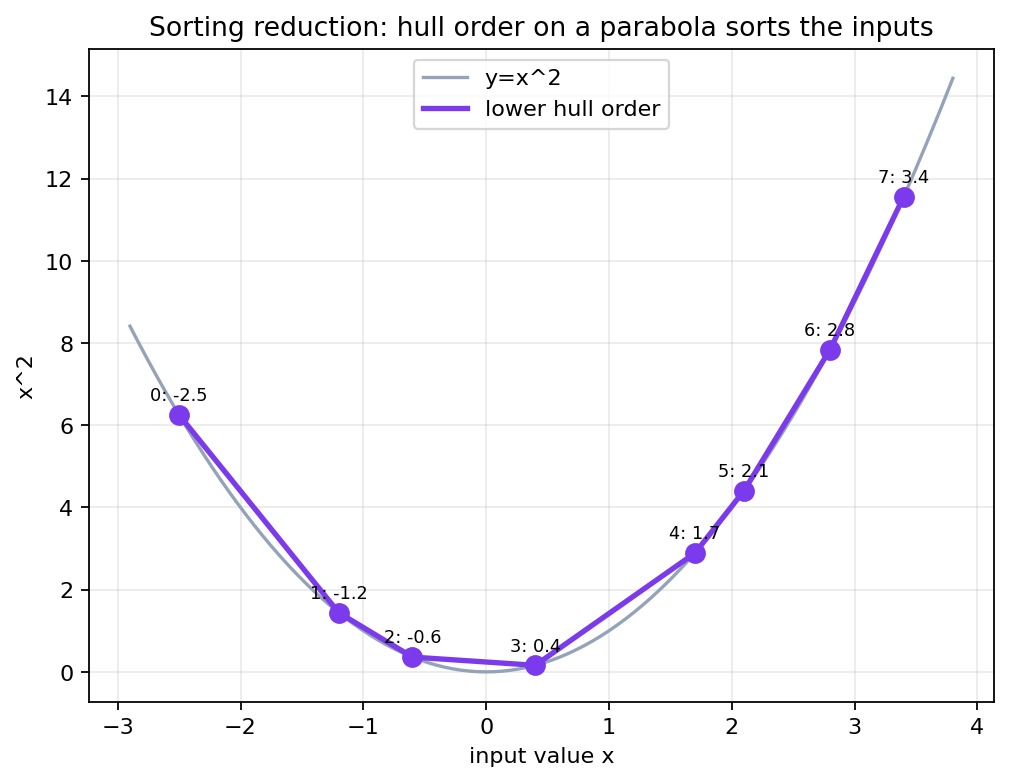

In [5]:
raw_values = np.array([3.4, -1.2, 2.1, -2.5, 0.4, 1.7, -0.6, 2.8])
parabola_points = np.column_stack([raw_values, raw_values ** 2])
# For a strictly convex upward parabola, sorting by x recovers the lower chain order.
sorted_indices = list(np.argsort(raw_values))
sorted_values = raw_values[sorted_indices]

fig, ax = plt.subplots(figsize=(7.3, 5.3))
xx = np.linspace(raw_values.min() - 0.4, raw_values.max() + 0.4, 200)
ax.plot(xx, xx ** 2, color="#94a3b8", linewidth=1.5, label="y=x^2")
ax.scatter(parabola_points[:, 0], parabola_points[:, 1], color="#7c3aed", s=70, zorder=3)
chain = parabola_points[sorted_indices]
ax.plot(chain[:, 0], chain[:, 1], color="#7c3aed", linewidth=2.4, label="lower hull order")
for rank, idx in enumerate(sorted_indices):
    p = parabola_points[idx]
    ax.text(p[0], p[1] + 0.35, f"{rank}: {raw_values[idx]:.1f}", ha="center", fontsize=8)
ax.set_title("Sorting reduction: hull order on a parabola sorts the inputs")
ax.set_xlabel("input value x")
ax.set_ylabel("x^2")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper center")
parabola_fig_path = save_matplotlib(fig, FIGURES / "parabola-sorting-reduction.png")
plt.close(fig)

parabola_path = save_json({
    "raw_values": [float(x) for x in raw_values],
    "hull_chain_order_values": [float(x) for x in sorted_values],
    "checks": {
        "parabola_hull_order_sorts_inputs": list(sorted_values) == sorted(raw_values),
        "all_parabola_points_are_extreme_on_chain": len(sorted_indices) == len(raw_values),
    },
}, CHECKS / "parabola-sorting-reduction.json")
display_artifact(parabola_fig_path, width=720)


## Complexity Laboratory and Extension Map

The chapter's algorithm comparisons become clearer when hull size is a parameter. Gift wrapping can beat an `O(n log n)` method when `h` is tiny, but it degrades to quadratic behavior when most points are on the hull. Graham scan is stable at `O(n log n)`. Kirkpatrick-Seidel style output-sensitive methods improve the bound to `O(n log h)`, showing that the best theoretical algorithms separate input size from output size. Incremental and divide-and-conquer methods fill out the design space: one is conceptually close to 3D hull construction, while the other relies on tangent merging after recursively solving left and right halves.


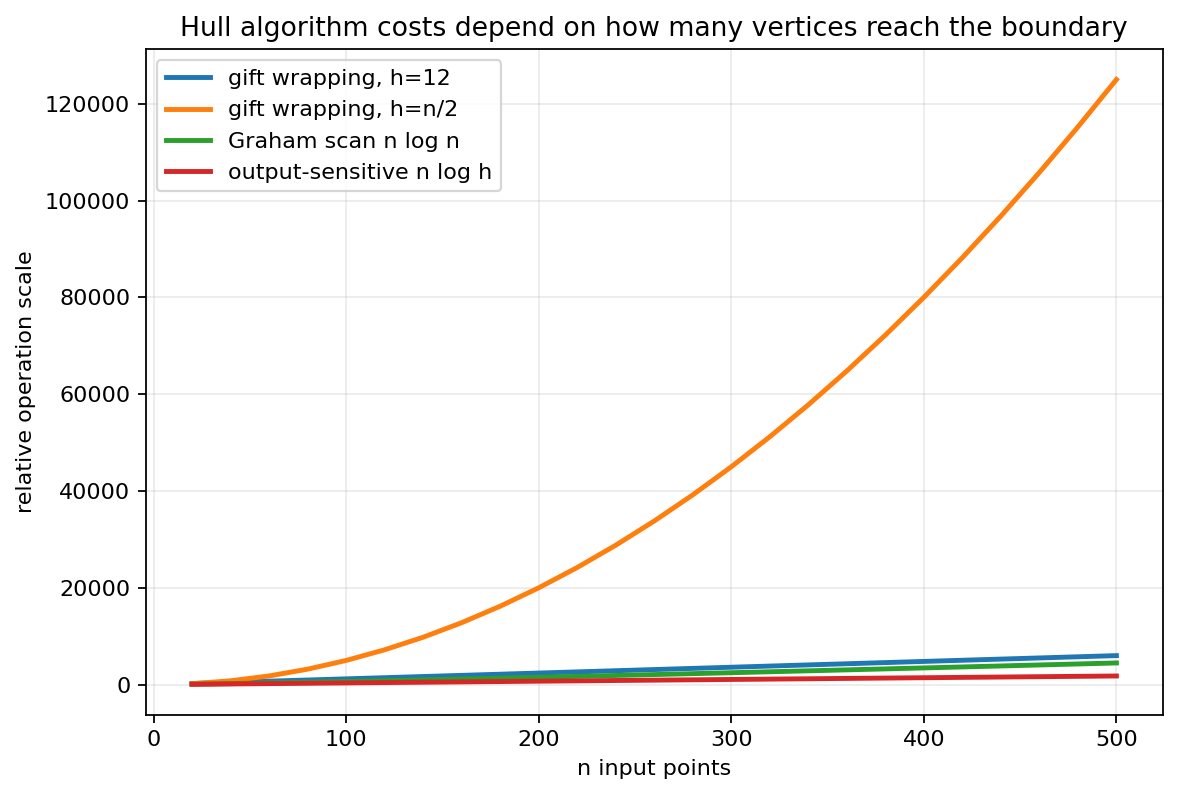

In [6]:
n = np.arange(20, 501, 20)
h_small = np.full_like(n, 12)
h_large = np.maximum(3, n // 2)
cost_rows = []
for nn, hs, hl in zip(n, h_small, h_large):
    cost_rows.append({
        "n": int(nn),
        "gift_wrap_h_12": int(nn * hs),
        "gift_wrap_h_n_over_2": int(nn * hl),
        "graham_n_log_n": float(nn * math.log2(nn)),
        "output_sensitive_n_log_12": float(nn * math.log2(hs)),
    })
complexity_table_path = save_csv(cost_rows, TABLES / "hull-complexity-costs.csv")

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.plot(n, [row["gift_wrap_h_12"] for row in cost_rows], label="gift wrapping, h=12", linewidth=2.2)
ax.plot(n, [row["gift_wrap_h_n_over_2"] for row in cost_rows], label="gift wrapping, h=n/2", linewidth=2.2)
ax.plot(n, [row["graham_n_log_n"] for row in cost_rows], label="Graham scan n log n", linewidth=2.2)
ax.plot(n, [row["output_sensitive_n_log_12"] for row in cost_rows], label="output-sensitive n log h", linewidth=2.2)
ax.set_title("Hull algorithm costs depend on how many vertices reach the boundary")
ax.set_xlabel("n input points")
ax.set_ylabel("relative operation scale")
ax.grid(True, alpha=0.25)
ax.legend()
complexity_fig_path = save_matplotlib(fig, FIGURES / "hull-complexity-lab.png")
plt.close(fig)

extension_rows = [
    {"topic": "incremental hull", "local_invariant": "maintain tangents to the current hull", "why_it_matters": "extends naturally to 3D beneath-beyond"},
    {"topic": "divide and conquer", "local_invariant": "merge two hulls along upper and lower tangents", "why_it_matters": "gives O(n log n) without angular sort"},
    {"topic": "rotating calipers", "local_invariant": "advance antipodal pairs around a convex polygon", "why_it_matters": "computes diameter, width, and related hull measurements"},
    {"topic": "onion peeling", "local_invariant": "repeat hull extraction", "why_it_matters": "turns hulls into depth layers"},
]
extension_table_path = save_csv(extension_rows, TABLES / "hull-extension-map.csv")
complexity_report_path = save_json({
    "sample_n_values": [int(x) for x in n[::5]],
    "checks": {
        "output_sensitive_cost_drops_when_h_is_small": cost_rows[-1]["output_sensitive_n_log_12"] < cost_rows[-1]["graham_n_log_n"],
        "gift_wrap_degrades_when_h_is_large": cost_rows[-1]["gift_wrap_h_n_over_2"] > cost_rows[-1]["graham_n_log_n"],
    },
}, CHECKS / "hull-complexity-lab.json")
display_artifact(complexity_fig_path, width=760)


## Applied Lab

Change the point set so almost every point lies on a circle. Gift wrapping should become expensive because `h` is close to `n`, while Graham scan's complexity story barely changes. Then move most points into the interior and keep only a small outer frame. Gift wrapping will look more attractive, and the output-sensitive curve will explain why hull size deserves to be part of the analysis. For a second lab, add collinear points to the boundary. The code currently keeps farthest collinear points in gift wrapping and pops non-left turns in Graham scan; changing those conventions will change whether boundary-collinear points appear in the output.


## Takeaways

The chapter teaches convex hulls by algorithmic contrast. Naive tests reveal the definitions but are too slow. Gift wrapping is simple and output-sensitive but can be quadratic. QuickHull often discards many points quickly but has a bad worst case. Graham scan is reliable because it converts geometry into sorting plus a stack invariant. The lower-bound argument shows that the `n log n` barrier is not an accident when the hull is output in cyclic order.

The checks in this notebook tie those ideas to executable evidence: the three algorithms agree on the hull set, nonextreme points have witness triangles, Graham's stack removes right turns, the parabola order sorts the inputs, and the complexity chart shows why `h` matters. That makes the notebook usable without the source PDF open while still preserving the source span's main information and computational spirit.


In [7]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 12,
    "checks": {
        "gift_quick_graham_agree": hull_sets_agree,
        "every_marked_point_has_witness_triangle": len(nonextreme_witness) > 0 and all(len(v) == 3 for v in nonextreme_witness.values()),
        "triangle_test_extremes_match_hull_set": set(extreme_by_triangle) == set(gift_ids),
        "stack_never_keeps_right_turn": all(orient(points[graham_ids[i-2]], points[graham_ids[i-1]], points[graham_ids[i]]) > -EPS for i in range(2, len(graham_ids))),
        "parabola_hull_order_sorts_inputs": list(sorted_values) == sorted(raw_values),
        "output_sensitive_cost_drops_when_h_is_small": cost_rows[-1]["output_sensitive_n_log_12"] < cost_rows[-1]["graham_n_log_n"],
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path),
        str(nonextreme_fig_path), str(nonextreme_path), str(comparison_fig_path), str(graham_trace_fig_path),
        str(graham_table_path), str(hull_report_path), str(parabola_fig_path), str(parabola_path),
        str(complexity_table_path), str(extension_table_path), str(complexity_fig_path), str(complexity_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "gift_quick_graham_agree": true,
    "every_marked_point_has_witness_triangle": true,
    "triangle_test_extremes_match_hull_set": true,
    "stack_never_keeps_right_turn": true,
    "parabola_hull_order_sorts_inputs": true,
    "output_sensitive_cost_drops_when_h_is_small": true
  }
}


C:\Users\rahul\AppData\Local\Temp\ipykernel_1180\3437477522.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))
